In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

from data_generation.differential_equations import PoissonSetup1LeastSquares
from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing
from utils import plot_real_valued_function, plot_block_sparsity, plot_block_submatrix_sparsity

from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem


from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor, convert_weight_to_tensor
from utils import evaluate_expression, print_model_size
from typing import Optional
import pickle
import csv

from typing import Optional
from train.train_loss import SurrogateLoss
from models import ConvolutionalNN_129x129
from train.train_utils import BatchIndicesIterator, pretty_print_loss
from train.soap import SOAP
from utils.set_seed import set_seed
import time
from tqdm import tqdm

----------------------------------------
2025-12-09 21:06:33 - Start Program
----------------------------------------


In [2]:
set_seed(2025)

In [3]:
mesh_config_path= repo_path + "/configs/poisson_setup1/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup1/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/poisson_setup1/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/poisson_setup1/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup1/test_dataset"
model_train_outputs_path = repo_path + "/results/poisson_setup1/model_train_outputs/rbno_physics_loss_pod_data_loss"
model_test_outputs_path = repo_path + "/results/poisson_setup1/model_test_outputs/rbno_physics_loss_pod_data_loss"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
poisson_least_squares = PoissonSetup1LeastSquares(mesh_args, function_space_args)

In [4]:
p_dof = load_npy(train_dataset_path+'/p_dof.npy')
p_vertex_values = load_npy(train_dataset_path+'/p_vertex_values.npy')
sigma_u_dof = load_npy(train_dataset_path+'/sigma_u_dof.npy')

In [5]:
print("p_dof shape: ", p_dof.shape)
print("p_vertex_values shape: ", p_vertex_values.shape)
print("sigma_u_dof shape: ", sigma_u_dof.shape)

p_dof shape:  (5000, 32768)
p_vertex_values shape:  (5000, 16641)
sigma_u_dof shape:  (5000, 230401)


In [6]:
mesh = poisson_least_squares.mesh
Vh = poisson_least_squares.Vh

In [7]:
torch_dtype = {
    'float16': torch.float16,
    'float32': torch.float32,
    'float64': torch.float64,
}

In [8]:
reference_loss_list = []
num_samples_for_reference_loss = 1
for i in range(num_samples_for_reference_loss):
    p_fc = dolfinx.fem.Function(Vh['p'])  
    p_fc.x.array[:] = p_dof[i]
    weight = poisson_least_squares.compute_weight(p_fc)
    weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])
    
    y = sigma_u_dof[i]
    y = torch.tensor(y, dtype=torch_dtype['float64'])
    reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
    print(f'reference loss: {reference_loss.item()}')
    reference_loss_list.append(reference_loss.item())

print(f"reference loss mean: {np.mean(reference_loss_list):.2e}")
print(f"reference loss std: {np.std(reference_loss_list):.2e}")

reference loss: 0.00010073986411485158
reference loss mean: 1.01e-04
reference loss std: 0.00e+00


In [9]:
def compute_reduced_weight(weight: dict[torch.Tensor], pod_basis_dof: torch.Tensor)-> torch.Tensor:

    quadratic_weight = pod_basis_dof.T @ weight['A00'] @ pod_basis_dof
    linear_weight = pod_basis_dof.T @ weight['A01']
    bias = weight['A11']

    reduced_weight = {'quadratic': quadratic_weight, 'linear': linear_weight, 'bias': bias}

    return reduced_weight

def compute_reduced_weight_v2(weight,  pod_basis_dof_petsc, pod_basis_dof_petsc_T) -> dict[np.ndarray]:
    """
    Compute the reduced weight using the POD basis in PETSc format.
    """
    temp = weight['A00'].matMult(pod_basis_dof_petsc)
    quadratic_weight = pod_basis_dof_petsc_T.matMult(temp)
    linear_weight = pod_basis_dof_petsc_T.createVecLeft()
    pod_basis_dof_petsc_T.mult(weight['A01'], linear_weight)
    bias = weight['A11']

    def mat_to_numpy(mat: PETSc.Mat):
        m, n = mat.getSize()
        arr = np.zeros((m, n), dtype=float)
        for i in range(m):
            for j in range(n):
                arr[i, j] = mat.getValue(i, j)
        return arr

    quadratic_weight = mat_to_numpy(quadratic_weight)
    linear_weight = linear_weight.getArray(readonly=True)
    reduced_weight = {'quadratic': quadratic_weight, 'linear': linear_weight, 'bias': bias}

    return reduced_weight

num_basis = 128

pod_basis_dof = np.load(train_dataset_path + '/hdiv_h1_pod_basis_dof.npy')[:, :num_basis]
pod_basis_dof_tensor = torch.tensor(pod_basis_dof, dtype=torch_dtype['float64'])

import numpy as np
from petsc4py import PETSc

pod_basis_dof_petsc = PETSc.Mat().createDense(size=pod_basis_dof.shape, array=pod_basis_dof, comm=PETSc.COMM_SELF)
pod_basis_dof_petsc_T = PETSc.Mat().createDense(size=(pod_basis_dof.shape[1], pod_basis_dof.shape[0]), array=pod_basis_dof.T, comm=PETSc.COMM_SELF)
pod_basis_dof_petsc.assemblyBegin()
pod_basis_dof_petsc.assemblyEnd()
pod_basis_dof_petsc_T.assemblyBegin()
pod_basis_dof_petsc_T.assemblyEnd()

In [10]:
%%time
weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])
reduced_weight = compute_reduced_weight(weight_tensor, pod_basis_dof_tensor)

CPU times: user 1.27 s, sys: 2.29 s, total: 3.56 s
Wall time: 3.54 s


In [11]:
%%time
reduced_weight_v2 = compute_reduced_weight_v2(weight, pod_basis_dof_petsc, pod_basis_dof_petsc_T)

CPU times: user 391 ms, sys: 111 ms, total: 501 ms
Wall time: 493 ms


In [12]:
# avg_compute_reduced_weight_time = 0
# for i in range(num_samples_for_reference_loss):
#     k_fc = dolfinx.fem.Function(Vh['k'])
#     k_fc.x.array[:] = k_dof[i]
#     weight = poisson_least_squares.compute_weight_with_auxiliary_variable(k_fc, aux_sigma_u)

#     start_time = time.time()
#     reduced_weight_v2 = compute_reduced_weight_v2(weight, pod_basis_dof_petsc, pod_basis_dof_petsc_T)
#     end_time = time.time()
#     avg_compute_reduced_weight_time += (end_time - start_time)
# avg_compute_reduced_weight_time /= num_samples_for_reference_loss
# print(avg_compute_reduced_weight_time)

In [13]:
# ## precision = float32
# reference_loss_list = []
# num_samples_for_reference_loss = 100
# aux_sigma_u = dolfinx.fem.Function(Vh['sigma_u'])
# aux_sigma_u.x.array[:] = aux_sigma_u_dof
# for i in range(num_samples_for_reference_loss):
#     k_fc = dolfinx.fem.Function(Vh['k'])  
#     k_fc.x.array[:] = k_dof[i]
#     weight = poisson_least_squares.compute_weight_with_auxiliary_variable(k_fc, aux_sigma_u)
#     weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float32'])
    
#     y = sigma_u_dof[i] - aux_sigma_u_dof
#     y = torch.tensor(y, dtype=torch_dtype['float32'])
#     reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
#     print(f'reference loss: {reference_loss.item()}')
#     reference_loss_list.append(reference_loss.item())


# print(f"reference loss mean: {np.mean(reference_loss_list):.2e}")
# print(f"reference loss std: {np.std(reference_loss_list):.2e}")

In [14]:
# # precision = float16
# reference_loss_list = []
# num_samples_for_reference_loss = 100
# aux_sigma_u = dolfinx.fem.Function(Vh['sigma_u'])
# aux_sigma_u.x.array[:] = aux_sigma_u_dof
# for i in range(num_samples_for_reference_loss):
#     k_fc = dolfinx.fem.Function(Vh['k'])  
#     k_fc.x.array[:] = k_dof[i]
#     weight = poisson_least_squares.compute_weight_with_auxiliary_variable(k_fc, aux_sigma_u)
#     weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float16'])
    
#     y = sigma_u_dof[i] - aux_sigma_u_dof
#     y = torch.tensor(y, dtype=torch_dtype['float16'])
#     reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
#     print(f'reference loss: {reference_loss.item()}')
#     reference_loss_list.append(reference_loss.item())

# print(f"reference loss mean: {np.mean(reference_loss_list):.2e}")
# print(f"reference loss std: {np.std(reference_loss_list):.2e}")

In [15]:
# fig = plot_block_sparsity(weight_tensor, highlight_box=(10000, 12000, 10000, 12000), box_color='red', box_linewidth=3, box_alpha=0.9)
# fig.savefig(os.path.join(train_dataset_path, 'sparsity_pattern_full.png'), dpi=300, bbox_inches='tight')

In [16]:
# fig = plot_block_submatrix_sparsity(weight_tensor, (10000, 12000), (10000, 12000), highlight_box=(0, 100, 0, 100), box_color='red', box_linewidth=2, box_alpha=0.5)
# fig.savefig(os.path.join(train_dataset_path, 'sparsity_pattern_10000-12000.png'), dpi=300, bbox_inches='tight')

In [17]:
# fig = plot_block_submatrix_sparsity(weight_tensor, (10000, 10100), (10000, 10100))
# fig.savefig(os.path.join(train_dataset_path, 'sparsity_pattern_10000-10100.png'), dpi=300, bbox_inches='tight')

In [18]:
# for i in range(10):
#     k_fc = dolfinx.fem.Function(Vh['k'])
#     k_fc.x.array[:] = k_dof[i]
#     weight = poisson_least_squares.compute_weight_with_auxiliary_variable(k_fc, aux_sigma_u)
#     weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])
    
#     y = sigma_u_dof[0] - aux_sigma_u_dof
#     y = torch.tensor(y, dtype=torch_dtype['float64'])
#     reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']

#     if i == 0:
#         print(f'Correct reference loss: {reference_loss}')
#     else: 
#         print(f'Wrong reference loss: {reference_loss}')

In [19]:
pod_basis_dof = np.load(train_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']]
reference_reduced_minimizers = np.load(train_dataset_path+'/reference_reduced_minimizers.npy')[:,:output_reduced_basis_args['num_basis']]

In [20]:
# for i in range(10):
#     plt.plot(pod_basis_dof[:,i])

In [21]:
pod_basis_dof = torch.tensor(pod_basis_dof, dtype=torch_dtype['float64'])
reference_reduced_minimizers = torch.tensor(reference_reduced_minimizers, dtype=torch_dtype['float64'])

quadratic_weight = torch.tensor(np.load(train_dataset_path+'/hdiv_h1_quadratic_weight.npy'), dtype=torch_dtype['float64'])
linear_weight = torch.tensor(np.load(train_dataset_path+'/hdiv_h1_linear_weight.npy'), dtype=torch_dtype['float64'])
bias = torch.tensor(np.load(train_dataset_path+'/hdiv_h1_bias.npy'), dtype=torch_dtype['float64'])

In [22]:
reduced_weight_list = []
for i in range(len(quadratic_weight)):
    reduced_weight = {}
    reduced_weight['quadratic'] = quadratic_weight[i]
    reduced_weight['linear'] = linear_weight[i]
    reduced_weight['bias'] = bias[i]
    reduced_weight_list.append(reduced_weight)

In [23]:
surrogate_loss = SurrogateLoss(reduced_weight_list)

In [24]:
valid_start_index = 4500
reference_surrogate_loss_list = []
num_samples_for_reference_surrogate_loss = 500
for i in range(valid_start_index, valid_start_index + num_samples_for_reference_surrogate_loss):
    print(f'sample {i}:')
    reference_surrogate_loss = surrogate_loss(reference_reduced_minimizers[i], i, sub_dim=64)
    print(f'reference surrogate loss: {reference_surrogate_loss.item()}')
    reference_surrogate_loss_list.append(reference_surrogate_loss.item())
print("")
print("number of POD basi: 64")
print(f'mean reference surrogate loss: {np.mean(reference_surrogate_loss_list):.2e}')
print(f'std reference surrogate loss: {np.std(reference_surrogate_loss_list):.2e}')

sample 4500:
reference surrogate loss: 0.00043160808264386397
sample 4501:
reference surrogate loss: 0.0008166741369290964
sample 4502:
reference surrogate loss: 0.00043653716075531257
sample 4503:
reference surrogate loss: 0.00027495829609969213
sample 4504:
reference surrogate loss: 0.00022582770016654763
sample 4505:
reference surrogate loss: 0.00018576886340060383
sample 4506:
reference surrogate loss: 0.00025749903907201777
sample 4507:
reference surrogate loss: 0.00023064808979356144
sample 4508:
reference surrogate loss: 0.00017224577095520388
sample 4509:
reference surrogate loss: 0.00014251010423005361
sample 4510:
reference surrogate loss: 0.00022094822162310734
sample 4511:
reference surrogate loss: 0.00016545408331958278
sample 4512:
reference surrogate loss: 0.0005317159920659176
sample 4513:
reference surrogate loss: 0.0003090513937227257
sample 4514:
reference surrogate loss: 9.764782060339705e-05
sample 4515:
reference surrogate loss: 0.00024325803515679034
sample 4516:

In [25]:
reference_surrogate_loss_list = []
for i in range(valid_start_index, valid_start_index + num_samples_for_reference_surrogate_loss):
    print(f'sample {i}:')
    reference_surrogate_loss = surrogate_loss(reference_reduced_minimizers[i], i, sub_dim=128)
    print(f'reference surrogate loss: {reference_surrogate_loss.item()}')
    reference_surrogate_loss_list.append(reference_surrogate_loss.item())
print("")
print("number of POD basi: 128")
print(f'mean reference surrogate loss: {np.mean(reference_surrogate_loss_list):.2e}')
print(f'std reference surrogate loss: {np.std(reference_surrogate_loss_list):.2e}')

sample 4500:
reference surrogate loss: 0.00010218305421294538
sample 4501:
reference surrogate loss: 0.0001230687282425258
sample 4502:
reference surrogate loss: 0.00011238575568350839
sample 4503:
reference surrogate loss: 0.00012242223835334798
sample 4504:
reference surrogate loss: 6.425059196391025e-05
sample 4505:
reference surrogate loss: 7.004457719506085e-05
sample 4506:
reference surrogate loss: 9.061663736242842e-05
sample 4507:
reference surrogate loss: 9.046295523718051e-05
sample 4508:
reference surrogate loss: 8.838564563484752e-05
sample 4509:
reference surrogate loss: 8.526154847898759e-05
sample 4510:
reference surrogate loss: 0.00014081604340288045
sample 4511:
reference surrogate loss: 0.00012143582778989526
sample 4512:
reference surrogate loss: 8.094461445273815e-05
sample 4513:
reference surrogate loss: 8.15948096621888e-05
sample 4514:
reference surrogate loss: 7.603310732196e-05
sample 4515:
reference surrogate loss: 0.00010740180345325534
sample 4516:
reference

In [26]:
# reference_surrogate_loss_list = []
# for i in range(valid_start_index, valid_start_index + num_samples_for_reference_surrogate_loss):
#     print(f'sample {i}:')
#     reference_surrogate_loss = surrogate_loss(reference_reduced_minimizers[i], i, sub_dim=256)
#     print(f'reference surrogate loss: {reference_surrogate_loss.item()}')
#     reference_surrogate_loss_list.append(reference_surrogate_loss.item())
# print("")
# print("number of POD basi: 256")
# print(f'mean reference surrogate loss: {np.mean(reference_surrogate_loss_list):.2e}')
# print(f'std reference surrogate loss: {np.std(reference_surrogate_loss_list):.2e}')

In [27]:
# reference_surrogate_loss_list = []
# for i in range(valid_start_index, valid_start_index + num_samples_for_reference_surrogate_loss):
#     print(f'sample {i}:')
#     reference_surrogate_loss = surrogate_loss(reference_reduced_minimizers[i], i, sub_dim=512)
#     print(f'reference surrogate loss: {reference_surrogate_loss.item()}')
#     reference_surrogate_loss_list.append(reference_surrogate_loss.item())
# print("")
# print("number of POD basi: 512")
# print(f'mean reference surrogate loss: {np.mean(reference_surrogate_loss_list):.2e}')
# print(f'std reference surrogate loss: {np.std(reference_surrogate_loss_list):.2e}')

In [28]:
# fig, ax = plt.subplots(figsize=(8, 6))  # Fixed figure size
# cax = ax.imshow(surrogate_loss.reduced_weight_list[0]['quadratic'].numpy(),  cmap='turbo')
# ax.set_xlabel('column index', fontsize=15)   
# ax.set_ylabel('row index', fontsize=15)
# ax.set_title('Reduced quadratic weight matrix', fontsize=15)
# ax.tick_params(axis='both', which='major', labelsize=13)
# ax.set_aspect('equal')
# cbar = fig.colorbar(cax, ax=ax)
# cbar.ax.tick_params(labelsize=13)  # Increase colorbar tick label font size

# fig.savefig(os.path.join(train_dataset_path, 'reduced_quadratic_weight_matrix_full.png'), dpi=300, bbox_inches='tight')

In [29]:
# fig, ax = plt.subplots(figsize=(8, 6))  # Fixed figure size
# cax = ax.imshow(surrogate_loss.reduced_weight_list[0]['quadratic'][:64,:64].numpy(),  cmap='turbo')
# ax.set_xlabel('column index', fontsize=15)   
# ax.set_ylabel('row index', fontsize=15)
# ax.set_title('Reduced quadratic weight matrix [0:64, 0:64]', fontsize=15)
# ax.tick_params(axis='both', which='major', labelsize=13)
# ax.set_aspect('equal')
# cbar = fig.colorbar(cax, ax=ax)
# cbar.ax.tick_params(labelsize=13)  # Increase colorbar tick label font size
# fig.savefig(os.path.join(train_dataset_path, 'reduced_quadratic_weight_matrix_0-64.png'), dpi=300, bbox_inches='tight')

In [30]:
# fig, ax = plt.subplots(figsize=(8, 6))  # Fixed figure size
# cax = ax.imshow(surrogate_loss.reduced_weight_list[0]['quadratic'][:16,:16].numpy(),  cmap='turbo')
# ax.set_xlabel('column index', fontsize=15) 
# ax.set_ylabel('row index', fontsize=15)
# ax.set_title('Reduced quadratic weight matrix [0:16, 0:16]', fontsize=15)
# ax.tick_params(axis='both', which='major', labelsize=13)
# ax.set_aspect('equal')
# cbar = fig.colorbar(cax, ax=ax)
# cbar.ax.tick_params(labelsize=13)  # Increase colorbar tick label font size
# fig.savefig(os.path.join(train_dataset_path, 'reduced_quadratic_weight_matrix_0-16.png'), dpi=300, bbox_inches='tight')

In [31]:
num_p_fc = len(p_dof)
dolfinx_mesh_coords = mesh.geometry.x[:,:2]

num_x, num_y = mesh_args['num_x'], mesh_args['num_y']
x = np.linspace(0, mesh_args['upper_right_x'], num_x+1)
y = np.linspace(0, mesh_args['upper_right_y'], num_y+1)
image_mesh_coords = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)
perm = [np.where((image_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]

CG_element = basix.ufl.element('CG', 'triangle', 1)
Vh['CG1'] = dolfinx.fem.functionspace(mesh, CG_element)

In [32]:
# for i in range(3):
#     k = dolfinx.fem.Function(Vh['CG1'])
#     k.x.array[:] = k_dof[i]
#     k_vertex_values[i][perm] = k.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])]
#     plt.imshow(k_vertex_values[i].reshape(num_x+1, num_y+1).T, extent=[0, 1, 0, 1], origin='lower', cmap='turbo')
#     plt.colorbar()
#     plt.title('Random parameter function k')
#     plt.show()

In [33]:
# if not os.path.exists(os.path.join(train_dataset_path, 'k_vertex_values.npy')):
#     print('Computing k_vertex_values...')
#     k_vertex_values = np.zeros((num_k_fc, (mesh_args['num_x'] + 1) * (mesh_args['num_y'] + 1)))
#     for i in tqdm(range(num_k_fc)):
#         k_fc = dolfinx.fem.Function(Vh['k'])
#         k_fc.x.array[:] = k_dof[i]
#         k_vertex_values[i][perm] = evaluate_expression(mesh, k_fc, mesh.geometry.x)[1][:, 0]
#     np.save(os.path.join(train_dataset_path, 'k_vertex_values.npy'), k_vertex_values)
# else:
#     k_vertex_values = np.load(os.path.join(train_dataset_path, 'k_vertex_values.npy'))

In [34]:
# k_vertex_values = np.zeros((num_k_fc, (mesh_args['num_x'] + 1) * (mesh_args['num_y'] + 1)))

# for i in tqdm(range(num_k_fc)):
#     k = dolfinx.fem.Function(Vh['k'])
#     k.x.array[:] = k_dof[i]
#     k_vertex_values[i][perm] = evaluate_expression(mesh, k, mesh.geometry.x)[1][:, 0]

In [35]:
image_p_vertex_values = np.zeros((num_p_fc, 1, mesh_args['num_y']+1, mesh_args['num_x']+1))
for i in tqdm(range(num_p_fc)):
    image_p_vertex_values[i,0,:,:] = p_vertex_values[i].reshape(num_x+1, num_y+1).T

100%|██████████| 5000/5000 [00:01<00:00, 4163.35it/s]


In [36]:
# for i in range(num_k_fc):
#     k = dolfinx.fem.Function(Vh['CG1'])
#     k.x.array[:] = k_dof[i]
#     k_vertex_values[i][perm] = k.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])]

# device = torch.device('cuda:3')

# image_k_vertex_values = np.zeros((num_k_fc, 1, num_x+1, num_y+1))
# for i in range(num_k_fc):
#     image_k_vertex_values[i,0,:,:] = k_vertex_values[i].reshape(num_x+1, num_y+1)

# k_vertex_values_tensor = torch.tensor(image_k_vertex_values, dtype=torch_dtype['float32']).to(device)

In [37]:
device = torch.device('cuda:1')
p_vertex_values_tensor = torch.tensor(image_p_vertex_values, dtype=torch_dtype['float32']).to(device)

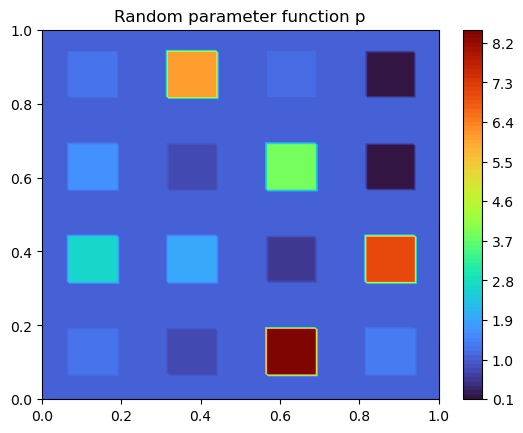

In [38]:
x = mesh.geometry.x[:, 0]
y = mesh.geometry.x[:, 1]
p = dolfinx.fem.Function(Vh['p'])
p.x.array[:] = p_dof[0]
plt.tricontourf(x, y, evaluate_expression(mesh, p, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
plt.colorbar()
plt.title('Random parameter function p')
plt.show()

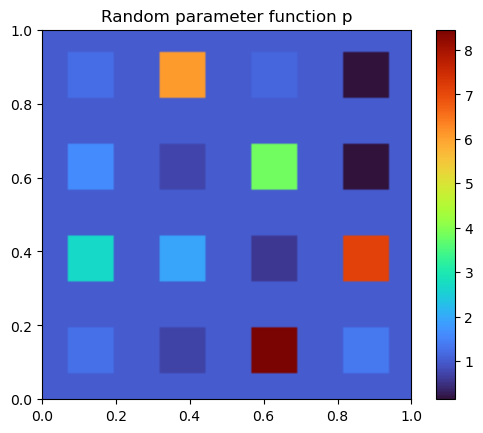

In [39]:
plt.imshow(p_vertex_values_tensor[0,0,:,:].cpu().numpy(), extent=[0, 1, 0, 1], origin='lower', cmap='turbo')
plt.colorbar()
plt.title('Random parameter function p')
plt.show()

In [40]:
surrogate_loss = SurrogateLoss(reduced_weight_list).astype(torch_dtype['float32']).to(device)
num_basis = output_reduced_basis_args['num_basis']
model = ConvolutionalNN_129x129(output_dim=num_basis, activation='leakyrelu', init_func='xavier_uniform')
model = model.to(device)

In [41]:
_, _ = print_model_size(model)

Total number of model parameters: 15117440 (~57.67 MiB)


In [42]:
iterations = 3000
num_train = 3000
num_valid = 500

batch_size = {
    'train': 1000,
    'valid': num_valid
}

In [43]:
data_loss = torch.nn.MSELoss(reduction='mean')
reference_reduced_minimizers = reference_reduced_minimizers.to(torch_dtype['float32']).to(device)
num_samples_for_data_loss = output_reduced_basis_args['num_evals']

In [44]:
loss_history = {
    'train_physical': [],
    'train_data': [],
    'train_total': [],
    'valid_physical': [],
    'valid_data': [],
    'valid_total': []
}
valid_start_index = 4500

train_batch_indices_iterator = BatchIndicesIterator(start=0, end=num_train, batch_size=batch_size['train'], shuffle=True)
valid_batch_indices_iterator = BatchIndicesIterator(start=valid_start_index, end=valid_start_index + num_valid, batch_size=batch_size['valid'], shuffle=False)
data_loss_indices = torch.arange(num_samples_for_data_loss, dtype=torch.int64).to(device)

print(f'num_training_samples: {num_train}')
optimizer = SOAP(params=model.parameters(), lr=5e-3, betas=(.95, .95), weight_decay=.01, precondition_frequency=5)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.9)

best_valid_loss = float('inf')
best_model_path = os.path.join(model_train_outputs_path, f"best_model_params_{num_train}.pth")
best_model_iterations = []  

counter = 0
while counter < iterations:
    for batch_indices in train_batch_indices_iterator:
        model.train()
        loss = {'physical': torch.tensor(0.0).to(device),
                'data': torch.tensor(0.0).to(device),
                'total': torch.tensor(0.0).to(device)}

        input_ = p_vertex_values_tensor[batch_indices]
        output = model(input_)

        data_loss_batch_indices = []
        for j, index in enumerate(batch_indices):
            loss['physical'] += (surrogate_loss(output[j], index))[0]
            if index in data_loss_indices:
                loss['data'] += data_loss(output[j], reference_reduced_minimizers[index])
                data_loss_batch_indices.append(index)

        loss['physical'] /= len(batch_indices)
        loss['data'] /= len(data_loss_batch_indices) if len(data_loss_batch_indices) > 0 else 1
        loss['total'] = loss['physical'] + loss['data']

        optimizer.zero_grad()
        loss['total'].backward()
        optimizer.step()
        counter += 1

        print('')
        print(f'Iteration: {counter}')
        print(f'Train loss: physical {loss["physical"].item()} | data {loss["data"].item()} | total {loss["total"].item()}')

        loss_history['train_physical'].append(loss['physical'].item())
        loss_history['train_data'].append(loss['data'].item())
        loss_history['train_total'].append(loss['total'].item())

        with torch.no_grad():
            model.eval()
            valid_loss = {'physical': torch.tensor(0.0).to(device),
                          'data': torch.tensor(0.0).to(device),
                          'total': torch.tensor(0.0).to(device)}
            for valid_batch_indices in valid_batch_indices_iterator:
                valid_input = p_vertex_values_tensor[valid_batch_indices]
                valid_output = model(valid_input)
                for j, index in enumerate(valid_batch_indices):
                    valid_loss['physical'] += (surrogate_loss(valid_output[j], index))[0]
                    valid_loss['data'] += data_loss(valid_output[j], reference_reduced_minimizers[index])
                valid_loss['physical'] /= len(valid_batch_indices)
                valid_loss['data'] /= len(valid_batch_indices)
                valid_loss['total'] = valid_loss['physical'] + valid_loss['data']

            valid_physical_loss_value = valid_loss['physical'].item()
            valid_data_loss_value = valid_loss['data'].item()
            valid_total_loss_value = valid_loss['total'].item()
            print(f'Valid loss: physical {valid_loss["physical"].item()} | data {valid_loss["data"].item()} | total {valid_loss["total"].item()}')

            loss_history['valid_physical'].append(valid_loss['physical'].item())
            loss_history['valid_data'].append(valid_loss['data'].item())
            loss_history['valid_total'].append(valid_loss['total'].item())

            # Save best model
            if valid_physical_loss_value < best_valid_loss:
                best_valid_loss = valid_physical_loss_value
                torch.save(model.state_dict(), best_model_path)
                best_model_iterations.append(counter) 
                print(f"New best model saved at iteration {counter} with validation physical loss {best_valid_loss:.6f}")

    lr_scheduler.step()

# Save training history and final model
loss_history = {key: np.array(value) for key, value in loss_history.items()}
np.save(os.path.join(model_train_outputs_path, f'loss_history_{num_train}.npy'), loss_history)
torch.save(model.state_dict(), os.path.join(model_train_outputs_path, f"latest_model_params_{num_train}.pth"))

num_training_samples: 3000

Iteration: 1
Train loss: physical 5.942257404327393 | data 0.017545700073242188 | total 5.959803104400635
Valid loss: physical 5.735286712646484 | data 0.017436577007174492 | total 5.752723217010498
New best model saved at iteration 1 with validation physical loss 5.735287

Iteration: 2
Train loss: physical 5.737150192260742 | data 0.017626848071813583 | total 5.754776954650879
Valid loss: physical 4479.44384765625 | data 4.9147047996521 | total 4484.3583984375

Iteration: 3
Train loss: physical 4481.59912109375 | data 5.132874965667725 | total 4486.73193359375
Valid loss: physical 554.0331420898438 | data 0.49348729848861694 | total 554.526611328125

Iteration: 4
Train loss: physical 562.8552856445312 | data 0.5199323296546936 | total 563.375244140625
Valid loss: physical 150.11871337890625 | data 0.1788540780544281 | total 150.2975616455078

Iteration: 5
Train loss: physical 140.7806854248047 | data 0.18092402815818787 | total 140.96160888671875
Valid loss

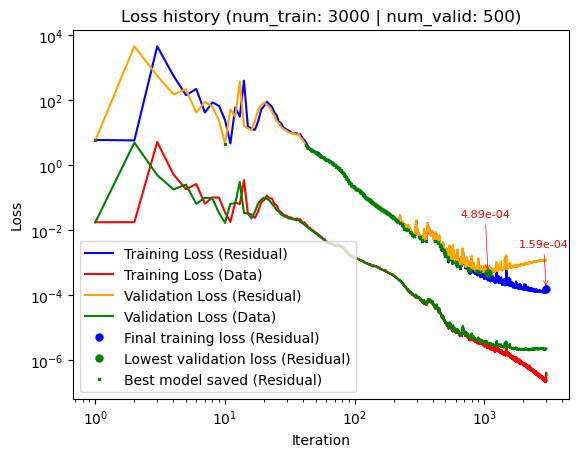

In [45]:
counter_indices = np.arange(1, len(loss_history['train_physical'])+1)
plt.loglog(counter_indices, loss_history['train_physical'], label='Training Loss (Residual)', color='blue')
plt.loglog(counter_indices, loss_history['train_data'], label='Training Loss (Data)', color='red')
plt.loglog(counter_indices, loss_history['valid_physical'], label='Validation Loss (Residual)', color='orange')
plt.loglog(counter_indices, loss_history['valid_data'], label='Validation Loss (Data)', color='green')
plt.plot(counter_indices[-1], loss_history['train_physical'][-1], 'bo', markersize=5, label='Final training loss (Residual)')  # blue dot on last point
plt.plot(best_model_iterations[-1], loss_history['valid_physical'][best_model_iterations[-1]-1], 'go', markersize=5, label='Lowest validation loss (Residual)')  # red dot for best model iteration
plt.plot(best_model_iterations, [loss_history['valid_physical'][i-1] for i in best_model_iterations], 'gx', markersize=2, label='Best model saved (Residual)')  # green dots for best model iterations
# Annotate the last value
plt.annotate(f'{loss_history['train_physical'][-1]:.2e}',
             xy=(counter_indices[-1], loss_history['train_physical'][-1]),
             xytext=(-20, 30),
             textcoords='offset points',
             color='red',
             fontsize=8,
             arrowprops=dict(arrowstyle='->', color='red', lw=0.5))

plt.annotate(f'{loss_history['valid_physical'][best_model_iterations[-1]-1]:.2e}',
                xy=(best_model_iterations[-1], loss_history['valid_physical'][best_model_iterations[-1]-1]),
                xytext=(-20, 40),
                textcoords='offset points',
                color='red',
                fontsize=8,
                arrowprops=dict(arrowstyle='->', color='red', lw=0.5))

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title(f'Loss history (num_train: {num_train} | num_valid: {num_valid})')
plt.legend()
plt.savefig(os.path.join(model_train_outputs_path, f'loss_history_{num_train}.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [46]:
model = ConvolutionalNN_129x129(output_dim=num_basis, activation='leakyrelu', init_func='xavier_uniform')
model.load_state_dict(torch.load(os.path.join(model_train_outputs_path, f"best_model_params_{num_train}.pth")))
model = model.to(device)

In [47]:
num_test = 500

test_p_dof = load_npy(test_dataset_path+'/p_dof.npy')[:num_test]
test_sigma_u_dof = load_npy(test_dataset_path+'/sigma_u_dof.npy')[:num_test]
test_p_vertex_values = load_npy(test_dataset_path+'/p_vertex_values.npy')[:num_test]

In [48]:
test_image_p_vertex_values = np.zeros((num_test, 1, mesh_args['num_y']+1, mesh_args['num_x']+1))
for i in tqdm(range(num_test)):
    test_image_p_vertex_values[i,0,:,:] = test_p_vertex_values[i].reshape(num_x+1, num_y+1).T

100%|██████████| 500/500 [00:00<00:00, 6500.52it/s]


In [49]:
test_p_vertex_values_tensor = torch.tensor(test_image_p_vertex_values, dtype=torch_dtype['float32']).to(device)

In [50]:
test_pod_coeff_pred  = model(test_p_vertex_values_tensor)
test_pod_coeff_pred = test_pod_coeff_pred.cpu().detach()
test_pred = test_pod_coeff_pred.to(torch.float64) @ pod_basis_dof.T
test_pred = test_pred.numpy()

In [51]:
np.save(os.path.join(model_test_outputs_path, "test_pred_sigma_u_dof.npy"), test_pred)

In [52]:
compute_squared_L2_norm = poisson_least_squares.compute_squared_L2_norm
compute_squared_hdiv_h1_norm = poisson_least_squares.compute_squared_hdiv_h1_norm

In [53]:
sigma_u_norm_dict = {
    'squared_L2': np.zeros(num_test),
    'avg_squared_L2': 0.0,
    'squared_hdiv_h1': np.zeros(num_test),
    'avg_squared_hdiv_h1': 0.0
}

In [54]:
for i in tqdm(range(num_test)):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = test_sigma_u_dof[i] 
    sigma_u_norm_dict['squared_L2'][i] = compute_squared_L2_norm(sigma_u_label_fc)
sigma_u_norm_dict['avg_squared_L2'] = np.mean(sigma_u_norm_dict['squared_L2'])

100%|██████████| 500/500 [00:02<00:00, 175.62it/s]


In [55]:
for i in tqdm(range(num_test)):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = test_sigma_u_dof[i]
    sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
    u_label_fc = sigma_u_label_fc.sub(1).collapse()
    sigma_u_norm_dict['squared_hdiv_h1'][i] = compute_squared_hdiv_h1_norm(sigma_label_fc, u_label_fc)
sigma_u_norm_dict['avg_squared_hdiv_h1'] = np.mean(sigma_u_norm_dict['squared_hdiv_h1'])

100%|██████████| 500/500 [00:07<00:00, 68.88it/s]


In [56]:
print(f"Average squared L2 norm of sigma_u: {sigma_u_norm_dict['avg_squared_L2']:.2e}")
print(f"Average squared H(div)xH1 norm of sigma_u: {sigma_u_norm_dict['avg_squared_hdiv_h1']:.2e}")

Average squared L2 norm of sigma_u: 2.54e-01
Average squared H(div)xH1 norm of sigma_u: 1.43e+00


In [57]:
sigma_u_error_dict = {
    'squared_L2': np.zeros(num_test),
    'relative_squared_L2': np.zeros(num_test),
    'squared_hdiv_h1': np.zeros(num_test),
    'relative_squared_hdiv_h1': np.zeros(num_test)
}

In [58]:
for i in tqdm(range(num_test)):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = test_sigma_u_dof[i]
    sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
    u_label_fc = sigma_u_label_fc.sub(1).collapse()

    sigma_u_pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_pred_fc.x.array[:] = test_pred[i]
    sigma_pred_fc = sigma_u_pred_fc.sub(0).collapse()
    u_pred_fc = sigma_u_pred_fc.sub(1).collapse()

    sigma_u_error_dict['squared_L2'][i] = compute_squared_L2_norm(sigma_u_label_fc - sigma_u_pred_fc)
    sigma_u_error_dict['relative_squared_L2'][i] = sigma_u_error_dict['squared_L2'][i] / sigma_u_norm_dict['avg_squared_L2']

    sigma_u_error_dict['squared_hdiv_h1'][i] = compute_squared_hdiv_h1_norm(sigma_label_fc - sigma_pred_fc, u_label_fc - u_pred_fc)
    sigma_u_error_dict['relative_squared_hdiv_h1'][i] = sigma_u_error_dict['squared_hdiv_h1'][i] / sigma_u_norm_dict['avg_squared_hdiv_h1']

100%|██████████| 500/500 [00:18<00:00, 27.53it/s]


In [59]:
sigma_u_error_dict['bochner_L2'] = np.sqrt(np.mean(sigma_u_error_dict['squared_L2']))
sigma_u_error_dict['relative_bochner_L2'] = np.sqrt(np.mean(sigma_u_error_dict['relative_squared_L2']))
sigma_u_error_dict['bochner_hdiv_h1'] = np.sqrt(np.mean(sigma_u_error_dict['squared_hdiv_h1']))
sigma_u_error_dict['relative_bochner_hdiv_h1'] = np.sqrt(np.mean(sigma_u_error_dict['relative_squared_hdiv_h1']))

sigma_u_error_dict['std_L2'] = np.std(np.sqrt(sigma_u_error_dict['squared_L2']))
sigma_u_error_dict['std_relative_L2'] = np.std(np.sqrt(sigma_u_error_dict['relative_squared_L2']))
sigma_u_error_dict['std_hdiv_h1'] = np.std(np.sqrt(sigma_u_error_dict['squared_hdiv_h1']))
sigma_u_error_dict['std_relative_hdiv_h1'] = np.std(np.sqrt(sigma_u_error_dict['relative_squared_hdiv_h1']))

In [60]:
print(f'sigma_u relative Bochner L2 error (std): {sigma_u_error_dict["relative_bochner_L2"]:.2e} ({sigma_u_error_dict["std_relative_L2"]:.2e})')
print(f'sigma_u relative Bochner H(div) x H1 error (std): {sigma_u_error_dict["relative_bochner_hdiv_h1"]:.2e} ({sigma_u_error_dict["std_relative_hdiv_h1"]:.2e})')

sigma_u relative Bochner L2 error (std): 2.25e-02 (7.69e-03)
sigma_u relative Bochner H(div) x H1 error (std): 1.71e-02 (5.38e-03)


In [61]:
np.save(os.path.join(model_test_outputs_path, "sigma_u_error_dict.npy"), sigma_u_error_dict)

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

In [63]:
def plot_ref_pred_diff(x, y, ref_f_grid_evals, pred_f_grid_evals, diff_f_grid_evals, variable_name, 
                        levels=100, 
                        ref_pred_format='%.3f',
                        ref_pred_colorbar_pad=0.02, 
                        diff_colorbar_pad=0.01,
                        tick_labelsize=15,  # NEW: control tick font size
                        colorbar_labelsize=15):  # NEW: control colorbar tick font size

    vmin = min(ref_f_grid_evals.min(), pred_f_grid_evals.min())
    vmax = max(ref_f_grid_evals.max(), pred_f_grid_evals.max())

    fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    # Reference
    cf0 = axs[0].tricontourf(x, y, ref_f_grid_evals, levels=levels, cmap='turbo', vmin=vmin, vmax=vmax)
    axs[0].set_title(fr'Reference {variable_name}', fontsize=18)
    axs[0].tick_params(axis='both', which='major', labelsize=tick_labelsize)
    axs[0].set_xticklabels([])
    axs[0].set_yticklabels([])


    # Prediction
    cf1 = axs[1].tricontourf(x, y, pred_f_grid_evals, levels=levels, cmap='turbo', vmin=vmin, vmax=vmax)
    axs[1].set_title(fr'Prediction {variable_name}', fontsize=18)
    axs[1].tick_params(axis='both', which='major', labelsize=tick_labelsize)
    axs[1].set_xticklabels([])
    axs[1].set_yticklabels([])

    # Shared colorbar for first two subplots
    cbar_shared = fig.colorbar(cf1, ax=[axs[0], axs[1]], format=ref_pred_format, pad=ref_pred_colorbar_pad)
    cbar_shared.ax.tick_params(labelsize=colorbar_labelsize)  # Increase colorbar ticks
    cbar_shared.locator = ticker.MaxNLocator(nbins=5)
    cbar_shared.update_ticks()

    # Difference plot (independent colorbar)
    cf2 = axs[2].tricontourf(x, y, diff_f_grid_evals, levels=levels, cmap='turbo')
    axs[2].set_title(fr'Difference {variable_name}', fontsize=18)
    axs[2].tick_params(axis='both', which='major', labelsize=tick_labelsize)
    axs[2].set_xticklabels([])
    axs[2].set_yticklabels([])

    cbar_diff = fig.colorbar(cf2, ax=axs[2], pad=diff_colorbar_pad)
    cbar_diff.ax.tick_params(labelsize=colorbar_labelsize)  # Increase colorbar ticks
    cbar_diff.formatter = ticker.ScalarFormatter(useMathText=True)
    cbar_diff.formatter.set_scientific(True)
    cbar_diff.formatter.set_powerlimits((-2, 2))
    cbar_diff.locator = ticker.MaxNLocator(nbins=5)
    cbar_diff.update_ticks()

    cbar_diff.ax.yaxis.get_offset_text().set_fontsize(colorbar_labelsize)

    # Remove ticks on x and y axes if needed
    for ax in axs:
        ax.tick_params(left=False, bottom=False)

    return fig

In [64]:
for i in range(3):
    # plt.figure(figsize=(6, 5))  # Optional: larger figure size
    img = plt.imshow(test_p_vertex_values_tensor[i,0,:,:].cpu().numpy(),
                     extent=[0, 1, 0, 1], origin='lower', cmap='turbo')

    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=16)  # Increase colorbar tick labels

    plt.title('parameter (setup 1)', fontsize=20)
    # plt.xticks(fontsize=16)
    # plt.yticks(fontsize=16)

    plt.savefig(os.path.join(model_test_outputs_path, f'test_p_{i}.png'),
                dpi=300, bbox_inches='tight')
    plt.close()

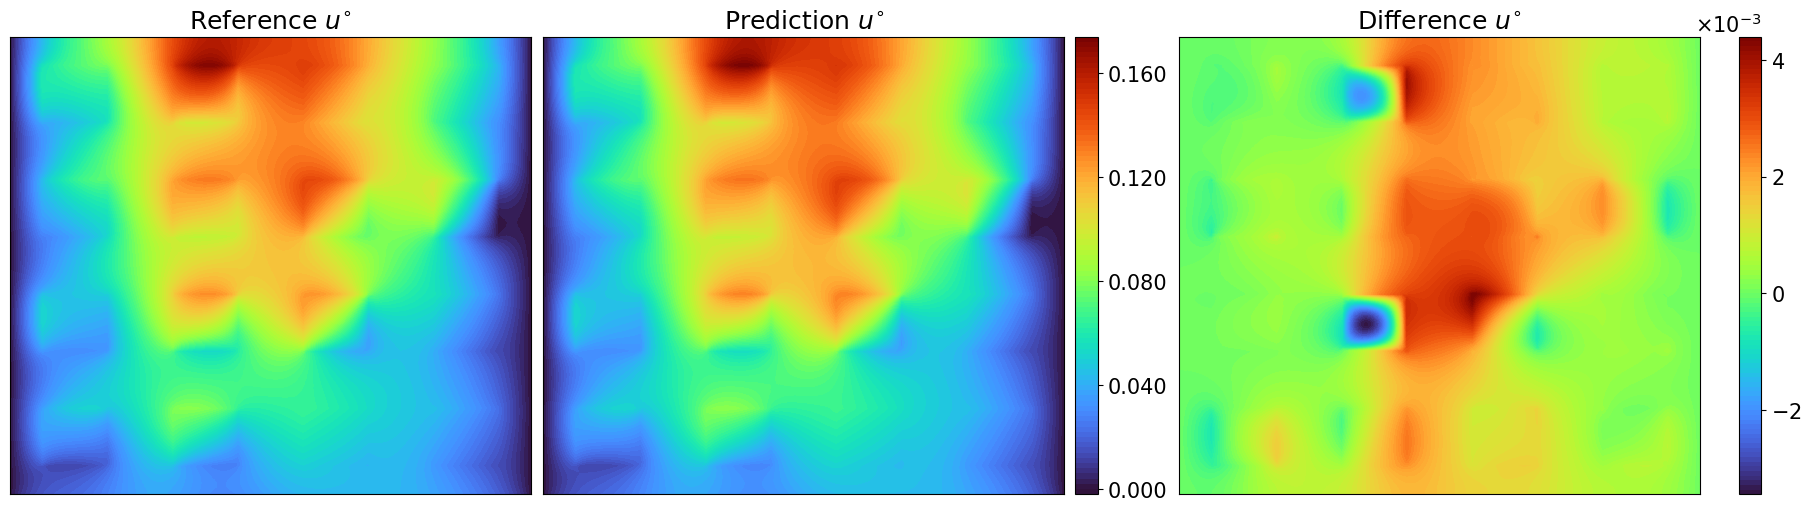

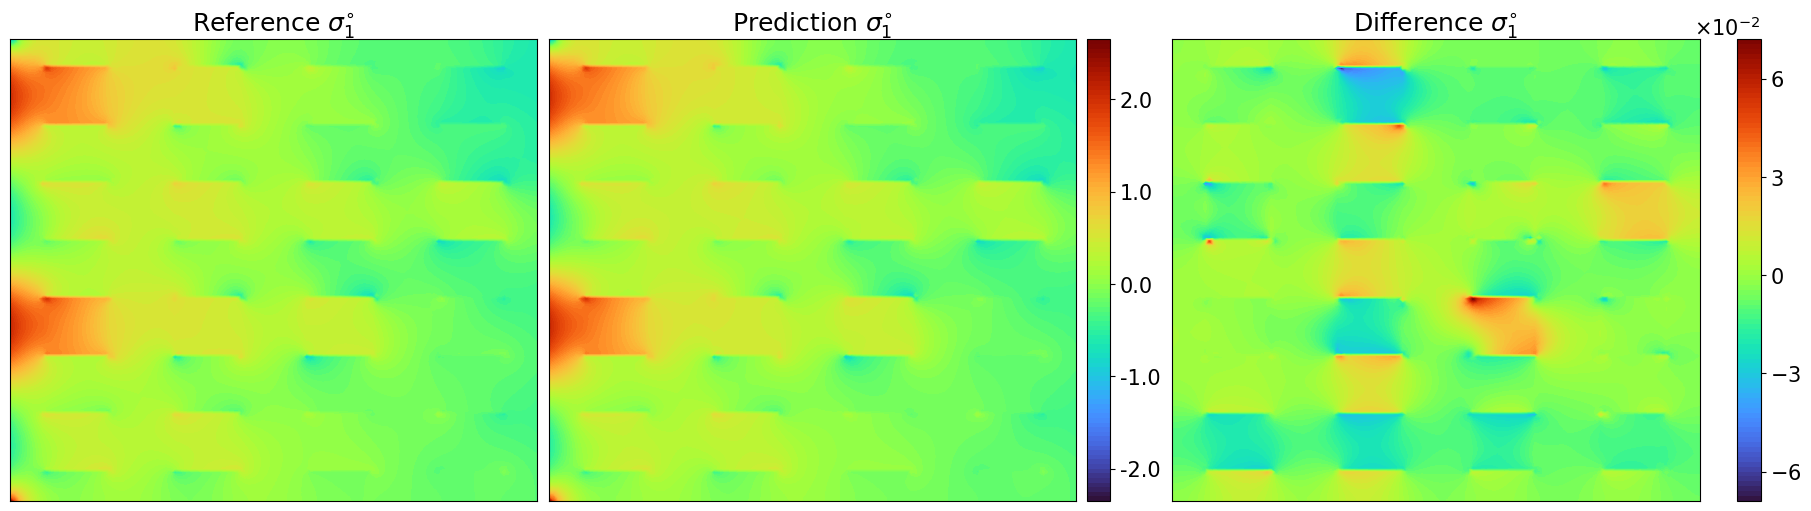

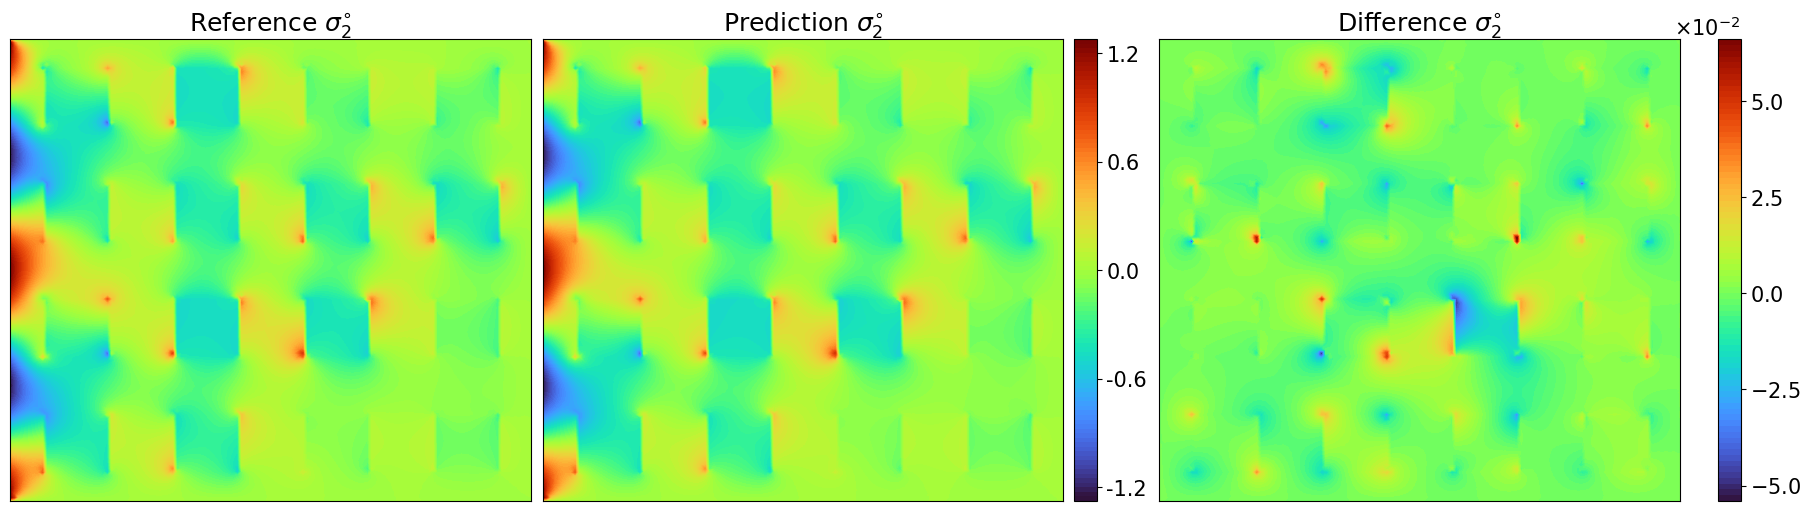

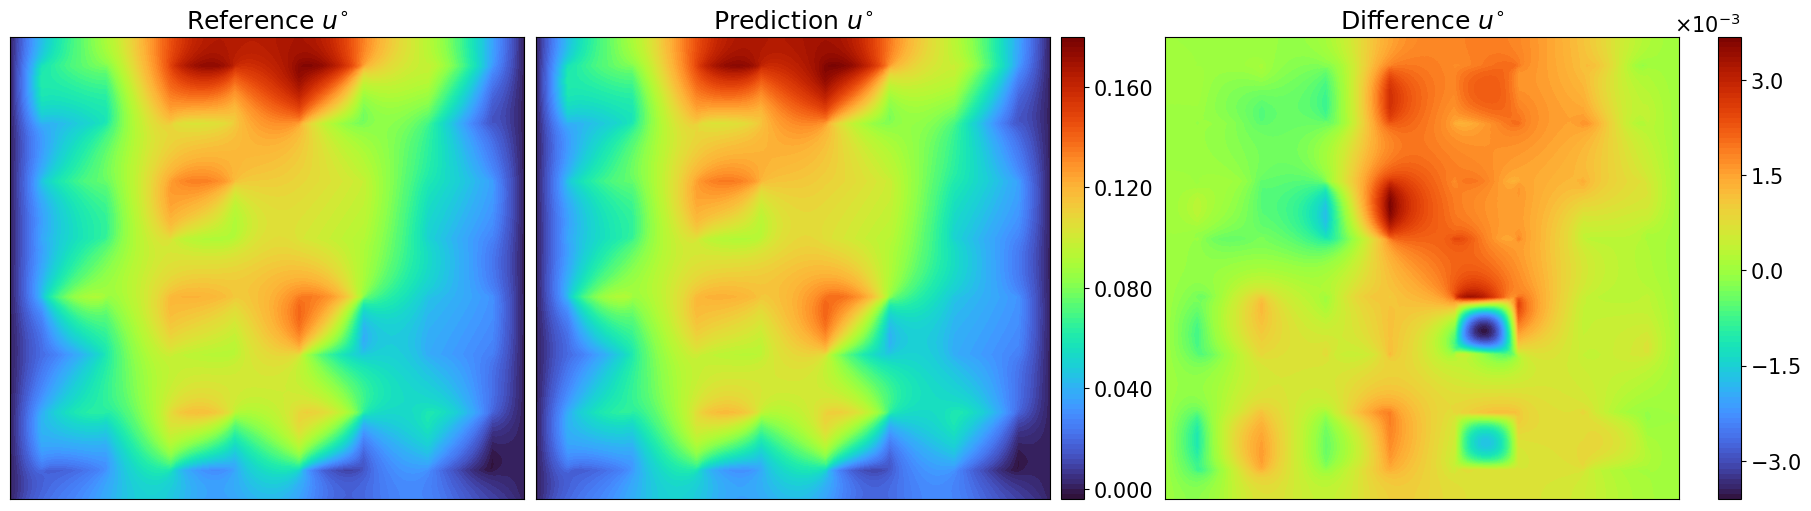

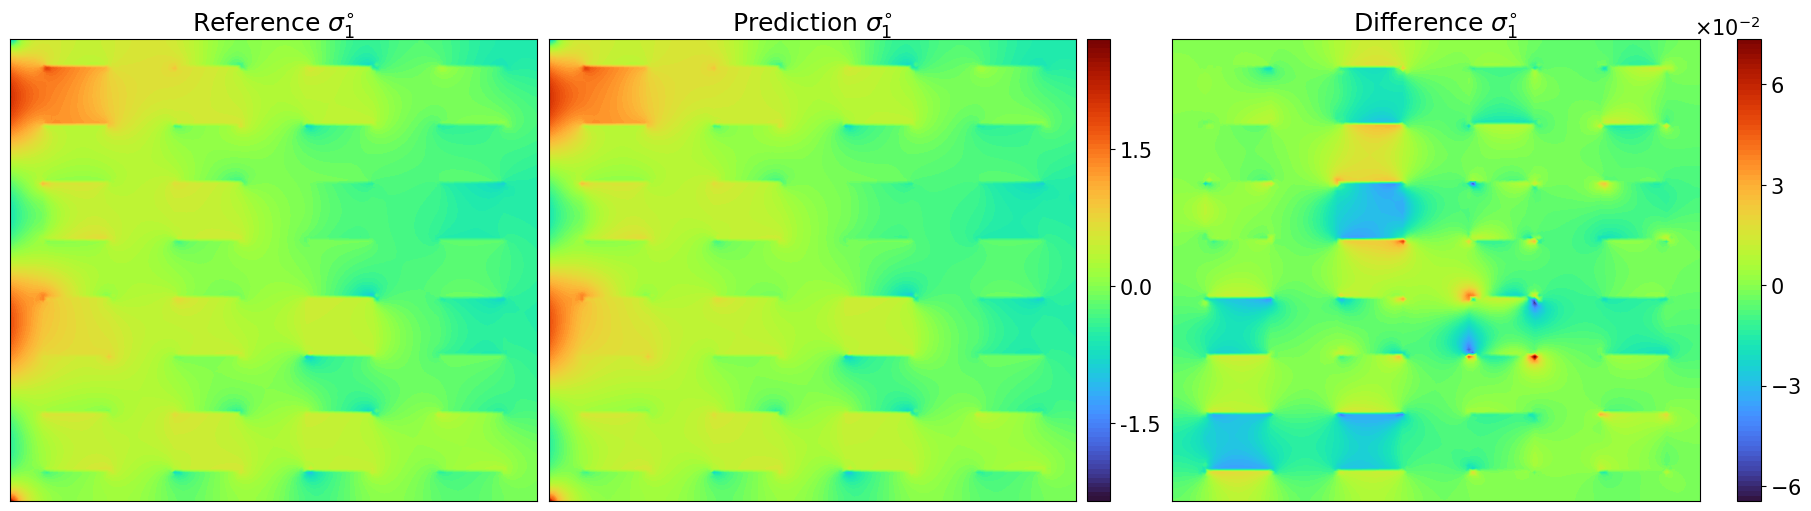

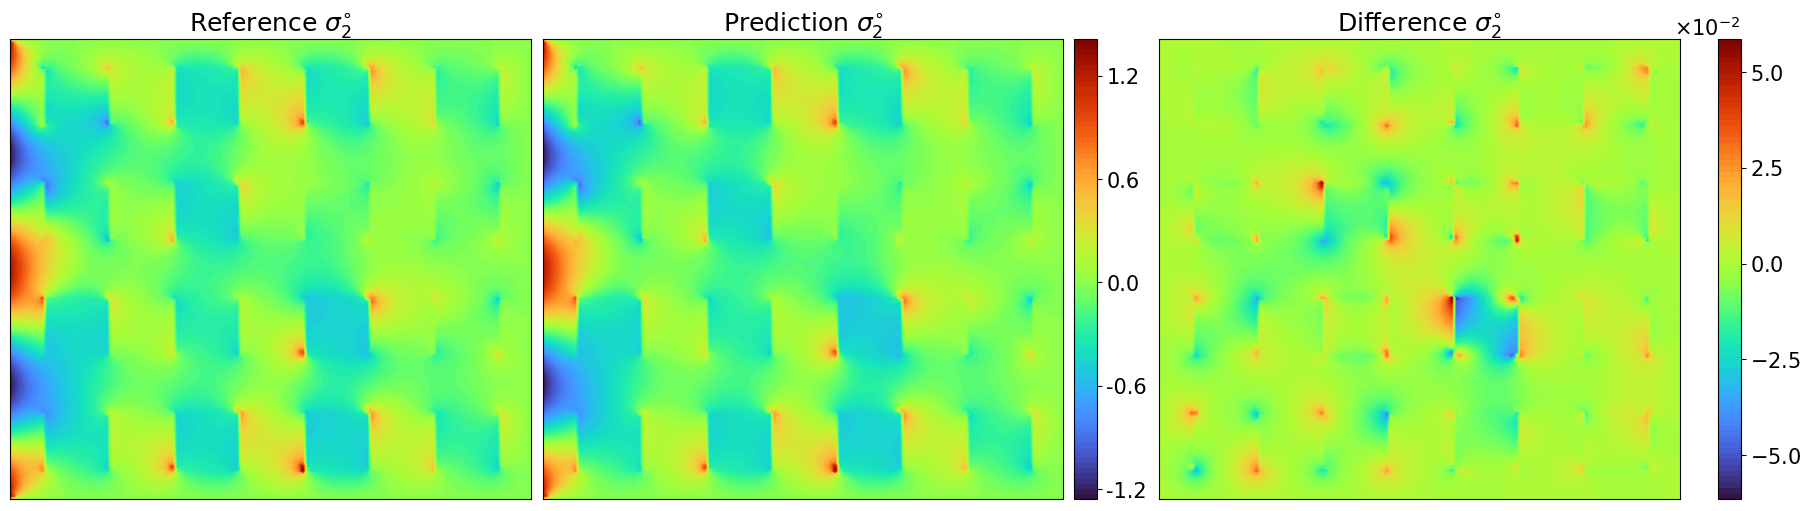

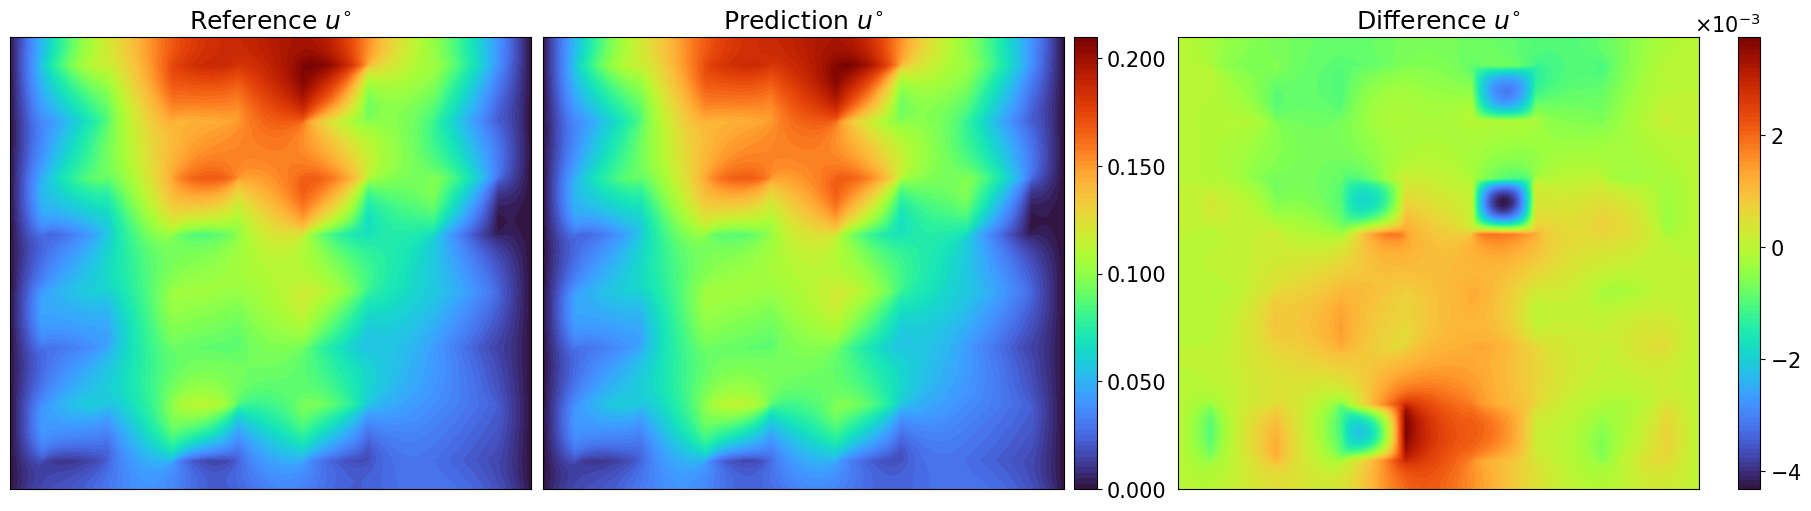

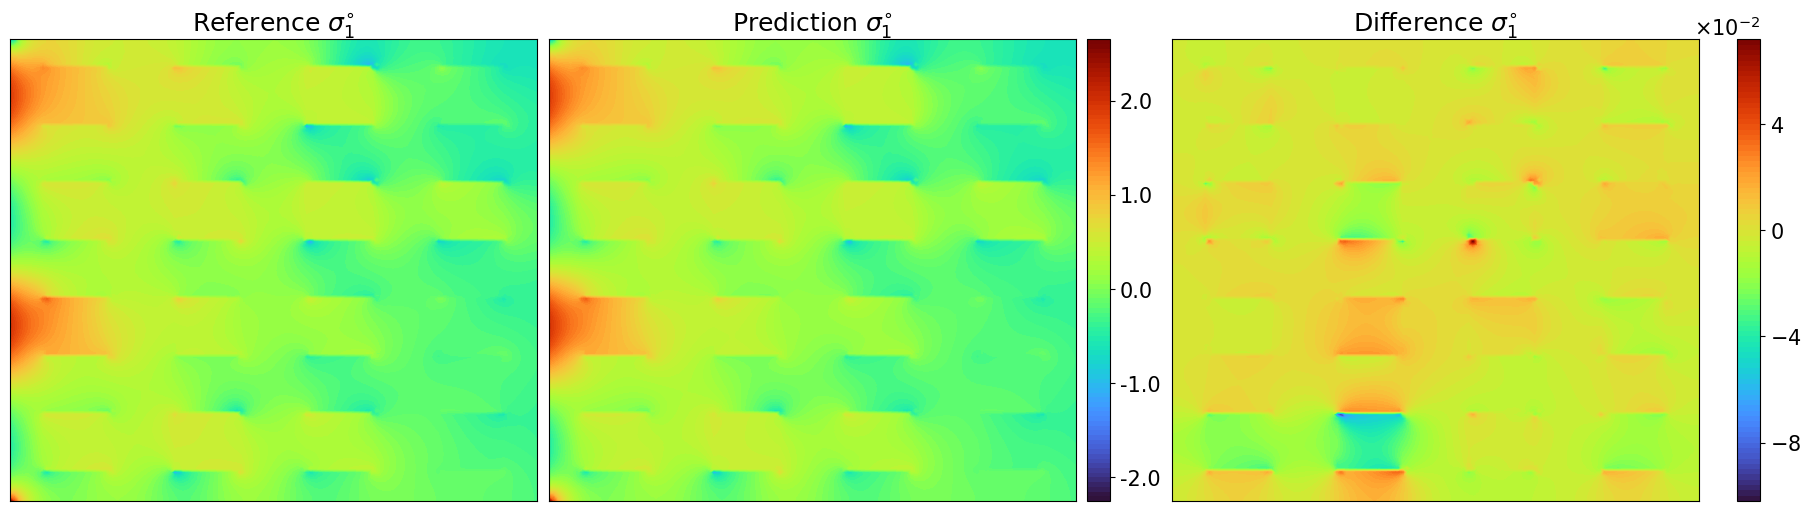

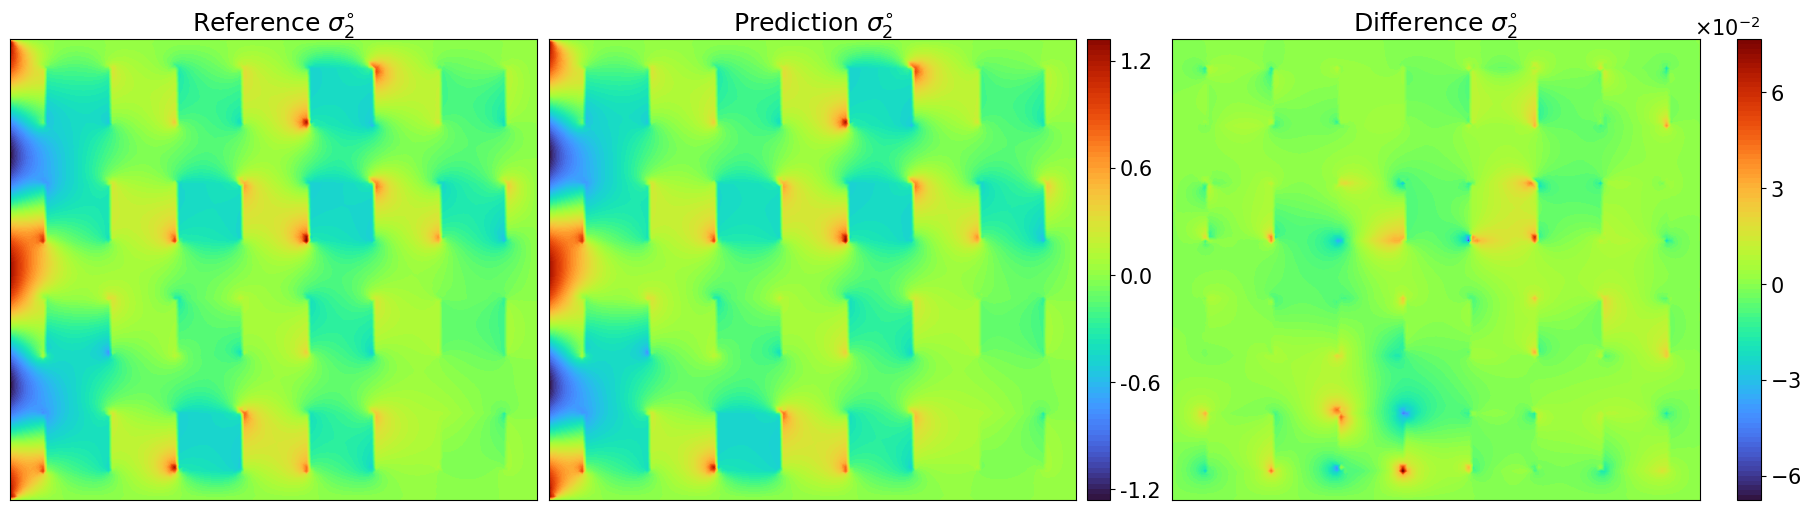

In [65]:
for test_sample_index in range(3):
    pred_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    pred_sigma_u_fc.x.array[:] = test_pred[test_sample_index]
    pred_sigma_fc = pred_sigma_u_fc.sub(0).collapse()
    pred_u_fc = pred_sigma_u_fc.sub(1).collapse()

    ref_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    ref_sigma_u_fc.x.array[:] = test_sigma_u_dof[test_sample_index]
    ref_sigma_fc = ref_sigma_u_fc.sub(0).collapse()
    ref_u_fc = ref_sigma_u_fc.sub(1).collapse()


    pred_sigma_grid_evals = evaluate_expression(mesh, pred_sigma_fc, mesh.geometry.x)[1]
    pred_u_grid_evals = evaluate_expression(mesh, pred_u_fc, mesh.geometry.x)[1]


    ref_sigma_grid_evals = evaluate_expression(mesh, ref_sigma_fc, mesh.geometry.x)[1]
    ref_u_grid_evals = evaluate_expression(mesh, ref_u_fc, mesh.geometry.x)[1]


    diff_sigma_grid_evals = pred_sigma_grid_evals - ref_sigma_grid_evals
    diff_u_grid_evals = pred_u_grid_evals - ref_u_grid_evals

    x = mesh.geometry.x[:, 0]
    y = mesh.geometry.x[:, 1]


    fig = plot_ref_pred_diff(x, y, ref_u_grid_evals[:,0], pred_u_grid_evals[:,0], diff_u_grid_evals[:,0], r'$u^{\circ}$',
                            levels=100,
                            ref_pred_format='%.3f',
                            ref_pred_colorbar_pad=0.01,
                            diff_colorbar_pad=-0.01)
    fig.savefig(os.path.join(model_test_outputs_path, f'u_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,0], pred_sigma_grid_evals[:, 0], diff_sigma_grid_evals[:, 0], r'$\sigma_1^{\circ}$', 
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.01, 
                            diff_colorbar_pad=-0.01)
    fig.savefig(os.path.join(model_test_outputs_path, f'sigma_1_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')


    fig = plot_ref_pred_diff(x, y, ref_sigma_grid_evals[:,1], pred_sigma_grid_evals[:, 1], diff_sigma_grid_evals[:, 1], r'$\sigma_2^{\circ}$', 
                            levels=100,
                            ref_pred_format='%.1f',
                            ref_pred_colorbar_pad=0.01, 
                            diff_colorbar_pad=-0.01)
    fig.savefig(os.path.join(model_test_outputs_path, f'sigma_2_ref_pred_diff_{test_sample_index}.png'), dpi=300, bbox_inches='tight')

In [66]:
compute_physical_loss_1 = poisson_least_squares.compute_physical_loss_1
compute_physical_loss_2 = poisson_least_squares.compute_physical_loss_2

In [67]:
residual_loss_dict = {
    'loss_1': np.zeros(num_test),
    'loss_2': np.zeros(num_test),
    'total_loss': np.zeros(num_test),
    'sqrt_total_loss': np.zeros(num_test)
}
for test_index in range(num_test): 
    pred_fc = dolfinx.fem.Function(Vh['sigma_u'])
    pred_fc.x.array[:] = test_pred[test_index]
    pred_sigma_fc = pred_fc.sub(0).collapse()
    pred_u_fc = pred_fc.sub(1).collapse()

    p_fc = dolfinx.fem.Function(Vh['p'])
    p_fc.x.array[:] = test_p_dof[test_index]

    residual_loss_1 = compute_physical_loss_1(pred_sigma_fc, pred_u_fc, p_fc)
    residual_loss_2 = compute_physical_loss_2(pred_sigma_fc, pred_u_fc, p_fc)

    residual_loss = residual_loss_1 + residual_loss_2

    sqrt_residual_loss = np.sqrt(residual_loss)

    residual_loss_dict['loss_1'][test_index] = residual_loss_1
    residual_loss_dict['loss_2'][test_index] = residual_loss_2
    residual_loss_dict['total_loss'][test_index] = residual_loss
    residual_loss_dict['sqrt_total_loss'][test_index] = sqrt_residual_loss
    print(f'Test sample {test_index}:')
    print(f'Residual loss 1: {residual_loss_1} | Residual loss 2: {residual_loss_2}')
    print(f'Total residual loss: {residual_loss} | Sqrt residual loss: {sqrt_residual_loss}')

    print("")

Test sample 0:
Residual loss 1: 0.00027672636048664686 | Residual loss 2: 6.350535561315729e-07
Total residual loss: 0.0002773614140427784 | Sqrt residual loss: 0.01665417107041892

Test sample 1:
Residual loss 1: 0.00041171330502899156 | Residual loss 2: 1.350954633087997e-07
Total residual loss: 0.0004118484004923004 | Sqrt residual loss: 0.020294048400757804

Test sample 2:
Residual loss 1: 0.000335289188835003 | Residual loss 2: 7.781648428589428e-07
Total residual loss: 0.0003360673536778619 | Sqrt residual loss: 0.018332139909946737

Test sample 3:
Residual loss 1: 0.0007000920334135296 | Residual loss 2: 5.412202339526076e-06
Total residual loss: 0.0007055042357530557 | Sqrt residual loss: 0.026561329706041744

Test sample 4:
Residual loss 1: 0.0002605827250994377 | Residual loss 2: 1.7831979307756681e-06
Total residual loss: 0.0002623659230302134 | Sqrt residual loss: 0.016197713512413208

Test sample 5:
Residual loss 1: 0.0006437992799813438 | Residual loss 2: 1.59461340728863

Test sample 20:
Residual loss 1: 0.0004006650950020202 | Residual loss 2: 4.0620376016991614e-07
Total residual loss: 0.00040107129876219014 | Sqrt residual loss: 0.020026764560512268

Test sample 21:
Residual loss 1: 0.0005372612633089038 | Residual loss 2: 5.352380718411615e-07
Total residual loss: 0.000537796501380745 | Sqrt residual loss: 0.023190439870359184

Test sample 22:
Residual loss 1: 0.0006195570148263194 | Residual loss 2: 1.347097189468605e-07
Total residual loss: 0.0006196917245452662 | Sqrt residual loss: 0.024893608106204015

Test sample 23:
Residual loss 1: 0.00033412499186329233 | Residual loss 2: 7.54872925477842e-09
Total residual loss: 0.00033413254059254713 | Sqrt residual loss: 0.018279292672107067

Test sample 24:
Residual loss 1: 0.0004478973600903649 | Residual loss 2: 1.1639282178768055e-06
Total residual loss: 0.0004490612883082417 | Sqrt residual loss: 0.021191066238116518

Test sample 25:
Residual loss 1: 0.0003397220269393885 | Residual loss 2: 2.783868

In [68]:
np.save(os.path.join(model_test_outputs_path, "residual_loss_dict.npy"), residual_loss_dict)

In [69]:
print(f'mean residual loss 1: {np.mean(residual_loss_dict["loss_1"]):.2e} (std: {np.std(residual_loss_dict["loss_1"]):.2e})')
print(f'mean residual loss 2: {np.mean(residual_loss_dict["loss_2"]):.2e} (std: {np.std(residual_loss_dict["loss_2"]):.2e})')
print(f'mean total residual loss: {np.mean(residual_loss_dict["total_loss"]):.2e} (std: {np.std(residual_loss_dict["total_loss"]):.2e})')
print(f'mean sqrt total residual loss: {np.mean(residual_loss_dict["sqrt_total_loss"]):.2e} (std: {np.std(residual_loss_dict["sqrt_total_loss"]):.2e})')

mean residual loss 1: 4.53e-04 (std: 2.67e-04)
mean residual loss 2: 1.39e-06 (std: 2.02e-06)
mean total residual loss: 4.55e-04 (std: 2.67e-04)
mean sqrt total residual loss: 2.06e-02 (std: 5.41e-03)


In [70]:
ratio_list = []
for test_index in range(num_test):
    ratio = np.sqrt(sigma_u_error_dict['squared_hdiv_h1'])[test_index] / residual_loss_dict['sqrt_total_loss'][test_index]
    ratio_list.append(ratio)
    print(f'index: {test_index} | ratio: {ratio}')

index: 0 | ratio: 1.3708890062944254
index: 1 | ratio: 1.0670771359216362
index: 2 | ratio: 1.1741998391082769
index: 3 | ratio: 1.5195683475077986
index: 4 | ratio: 0.8916814223921812
index: 5 | ratio: 0.4915188560380252
index: 6 | ratio: 1.2713021694170392
index: 7 | ratio: 1.2633398230188317
index: 8 | ratio: 0.9184765891000786
index: 9 | ratio: 1.0320472735013642
index: 10 | ratio: 0.7423723856011656
index: 11 | ratio: 0.7499395610689552
index: 12 | ratio: 0.9439017758938948
index: 13 | ratio: 1.0256466114900804
index: 14 | ratio: 0.42878685137266737
index: 15 | ratio: 0.6850822210075153
index: 16 | ratio: 0.8617187844589346
index: 17 | ratio: 1.2001160362278456
index: 18 | ratio: 1.4190185133574187
index: 19 | ratio: 1.137816777285812
index: 20 | ratio: 1.052402666614741
index: 21 | ratio: 0.8317225557028767
index: 22 | ratio: 0.76196373022856
index: 23 | ratio: 1.0862066360636926
index: 24 | ratio: 0.6110373057537791
index: 25 | ratio: 0.8817493061255182
index: 26 | ratio: 1.2407

In [71]:
plt.figure(figsize=(8, 6))  # Optional: bigger figure
plt.hist(ratio_list, bins=10)

plt.xlabel('Value', fontsize=25) 
plt.ylabel('Frequency', fontsize=25)
plt.title(fr'Error / $\sqrt{{\text{{Loss}}}}$ (# test = {num_test})', fontsize=25)

plt.xticks(fontsize=23)
plt.yticks(fontsize=23)

plt.savefig(os.path.join(model_test_outputs_path, 'ratio_histogram_hdiv_h1.png'),
            dpi=300, bbox_inches='tight')
plt.close()